# Búsqueda de imágenes por texto (CLIP)

Carga un modelo entrenado desde `checkpoints/`, recibe una consulta de texto y recupera las
N imágenes más similares del dataset **flickr8k**, mostrando el texto de la consulta junto a
las imágenes encontradas.

Ajusta la celda de **configuración** y ejecuta las celdas en orden.

## 1. Configuración

In [2]:
import os

# Ruta a un checkpoint concreto (.ckpt). Si es None, se autodetecta el mejor de checkpoints/.
CHECKPOINT_PATH = None

# Raíz del proyecto (carpeta padre de notebooks/).
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
DATASET_DIR = os.path.join(PROJECT_ROOT, "datasets", "flickr8k")

TEXT_ENCODER_ALIAS = "distilbert-base-uncased"
IMAGE_SIZE = 224

# Número de imágenes a recuperar y mostrar (configurable).
N_RESULTS = 9

# Tamaño de lote para calcular los embeddings de las imágenes.
BATCH_SIZE = 64

## 2. Imports

In [3]:
import sys
import glob
import math
import re

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import albumentations as A
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer

# Hacer importable el paquete src/ del proyecto.
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from models.clip_model import CLIPModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

/home/miguel/miniconda3/envs/clip/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 3. Localizar el checkpoint

Si `CHECKPOINT_PATH` es `None`, se toma la carpeta de experimento más reciente y, dentro, el
checkpoint `epoch_*_val_loss_*/model.ckpt` con menor `val_loss` (o `last.ckpt` como fallback).

In [4]:
def find_best_checkpoint(checkpoints_dir):
    experiments = sorted(glob.glob(os.path.join(checkpoints_dir, "*")))
    experiments = [d for d in experiments if os.path.isdir(d)]
    if not experiments:
        raise FileNotFoundError(f"No hay experimentos en {checkpoints_dir!r}")
    experiment = experiments[-1]  # el más reciente (nombre con timestamp ordenable)

    best_ckpts = glob.glob(os.path.join(experiment, "epoch_*_val_loss_*", "model.ckpt"))

    def val_loss_of(path):
        m = re.search(r"val_loss_([0-9.]+)", path)
        return float(m.group(1)) if m else float("inf")

    if best_ckpts:
        return min(best_ckpts, key=val_loss_of)

    last_ckpt = os.path.join(experiment, "last.ckpt")
    if os.path.isfile(last_ckpt):
        return last_ckpt
    raise FileNotFoundError(f"No se encontró ningún .ckpt en {experiment!r}")


if CHECKPOINT_PATH is None:
    CHECKPOINT_PATH = find_best_checkpoint(CHECKPOINTS_DIR)

print("Checkpoint:", CHECKPOINT_PATH)

Checkpoint: /home/miguel/projects/clip_implementation/checkpoints/CLIP-2026-07-08_00-05-36/epoch_02_val_loss_0.5279/model.ckpt


## 4. Cargar el modelo

In [5]:
model = CLIPModel.load_from_checkpoint(CHECKPOINT_PATH, map_location=DEVICE)
model.eval().to(DEVICE)
print("Modelo cargado desde:", CHECKPOINT_PATH)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4097.52it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado desde: /home/miguel/projects/clip_implementation/checkpoints/CLIP-2026-07-08_00-05-36/epoch_02_val_loss_0.5279/model.ckpt


## 5. Lista de imágenes únicas del dataset

In [6]:
annotations = pd.read_csv(os.path.join(DATASET_DIR, "captions.txt"))
image_filenames = annotations["image"].unique().tolist()
image_paths = [os.path.join(DATASET_DIR, "Images", f) for f in image_filenames]
print(f"{len(image_paths)} imágenes únicas")

8091 imágenes únicas


## 6. Calcular los embeddings de todas las imágenes

Se replica el mismo preprocesado que en entrenamiento (cv2 BGR→RGB, `Resize`, `Normalize`).
Este paso recorre las ~8091 imágenes una sola vez; en CPU puede tardar unos minutos.

In [7]:
transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE, always_apply=True),
    A.Normalize(max_pixel_value=255.0, always_apply=True),
])


def preprocess_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transforms(image=image)["image"]
    return torch.tensor(image).permute(2, 0, 1).float()


@torch.no_grad()
def compute_image_embeddings(paths, batch_size=BATCH_SIZE):
    embeddings = []
    for start in tqdm(range(0, len(paths), batch_size), desc="Imágenes"):
        batch_paths = paths[start:start + batch_size]
        batch = torch.stack([preprocess_image(p) for p in batch_paths]).to(DEVICE)
        features = model.image_encoder(batch)
        embeddings.append(model.image_projection(features).cpu())
    return torch.cat(embeddings)


image_embeddings = compute_image_embeddings(image_paths)
print("image_embeddings:", tuple(image_embeddings.shape))

/tmp/ipykernel_7619/3379233335.py:2: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(IMAGE_SIZE, IMAGE_SIZE, always_apply=True),
/tmp/ipykernel_7619/3379233335.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0, always_apply=True),
Imágenes: 100%|██████████| 127/127 [00:21<00:00,  5.84it/s]

image_embeddings: (8091, 256)


## 7. Buscar coincidencias para una consulta de texto

In [8]:
tokenizer = AutoTokenizer.from_pretrained(TEXT_ENCODER_ALIAS)


@torch.no_grad()
def find_matches(query, n=N_RESULTS):
    encoded = tokenizer([query], padding=True, truncation=True, return_tensors="pt")
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    text_features = model.text_encoder(
        input_ids=encoded["input_ids"], attention_mask=encoded["attention_mask"]
    )
    text_embeddings = model.text_projection(text_features).cpu()

    image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
    text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
    similarity = text_embeddings_n @ image_embeddings_n.T

    _, indices = torch.topk(similarity.squeeze(0), n)
    return [image_paths[i] for i in indices.tolist()]

## 8. Mostrar la consulta y las imágenes encontradas

In [12]:
def show_results(query, n=N_RESULTS):
    matches = find_matches(query, n=n)

    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    for ax, path in zip(axes, matches):
        image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.axis("off")
    for ax in axes[len(matches):]:
        ax.axis("off")

    fig.suptitle(f'Query: "{query}"  —  top {n}', fontsize=16)
    plt.tight_layout()
    plt.show()

## 9. Ejemplo de uso

Cambia el texto de la consulta y `N_RESULTS` para probar.

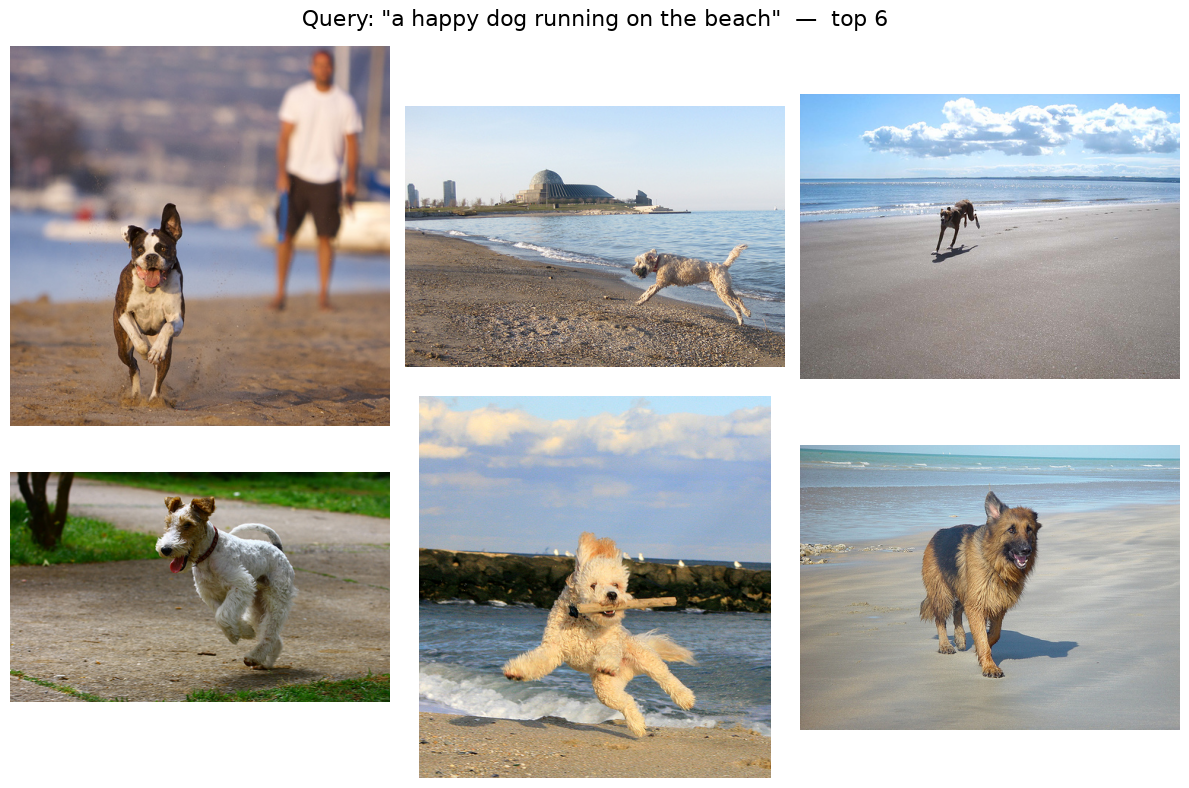

In [23]:
show_results("a happy dog running on the beach", n=6)